<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_057_probability_calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 57/365 — Probability Calibration
## If a model says 80%, should it be right about 80% of the time?

Yesterday we explored **Feature Interactions**.

Today we move to **Probability Calibration**.

A classifier can rank cases well and still output unreliable probabilities.

Calibration asks:

> Can we trust the probability itself, not just the predicted class?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import accuracy_score, log_loss


## 1. Load a real dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)
print("Dataset shape:",X.shape)


Dataset shape: (569, 30)


## 2. Train Logistic Regression and Random Forest


In [3]:
log_reg=LogisticRegression(max_iter=5000)
rf=RandomForestClassifier(n_estimators=300,random_state=42,n_jobs=-1)

log_reg.fit(X_train,y_train)
rf.fit(X_train,y_train)

log_prob=log_reg.predict_proba(X_test)[:,1]
rf_prob=rf.predict_proba(X_test)[:,1]

print("Logistic Regression Accuracy:",round(accuracy_score(y_test,(log_prob>=0.5).astype(int)),3))
print("Random Forest Accuracy:",round(accuracy_score(y_test,(rf_prob>=0.5).astype(int)),3))


Logistic Regression Accuracy: 0.958
Random Forest Accuracy: 0.958


## 3. Calibration curve

Perfect calibration lies near the diagonal:

`Predicted 0.7 → roughly 70% actually positive`


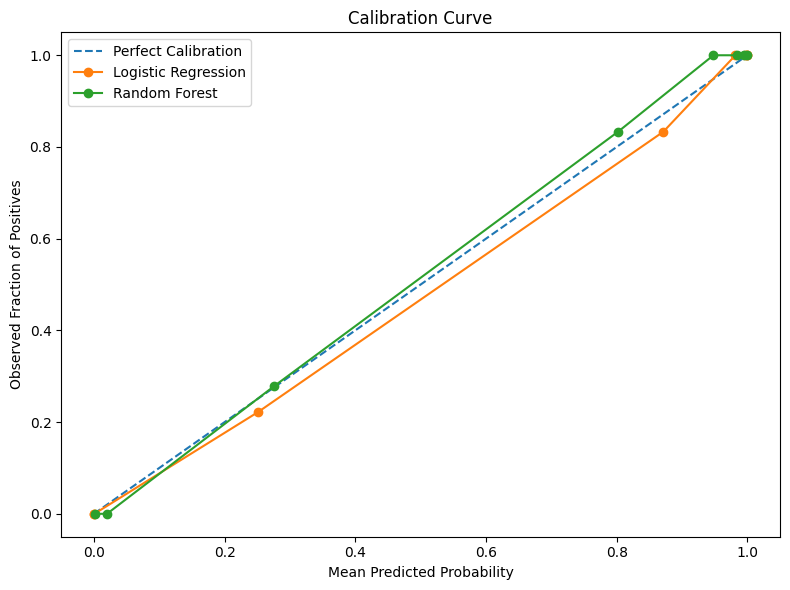

In [4]:
log_true,log_predicted=calibration_curve(y_test,log_prob,n_bins=8,strategy="quantile")
rf_true,rf_predicted=calibration_curve(y_test,rf_prob,n_bins=8,strategy="quantile")

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],linestyle="--",label="Perfect Calibration")
plt.plot(log_predicted,log_true,marker="o",label="Logistic Regression")
plt.plot(rf_predicted,rf_true,marker="o",label="Random Forest")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Calibrate the Random Forest


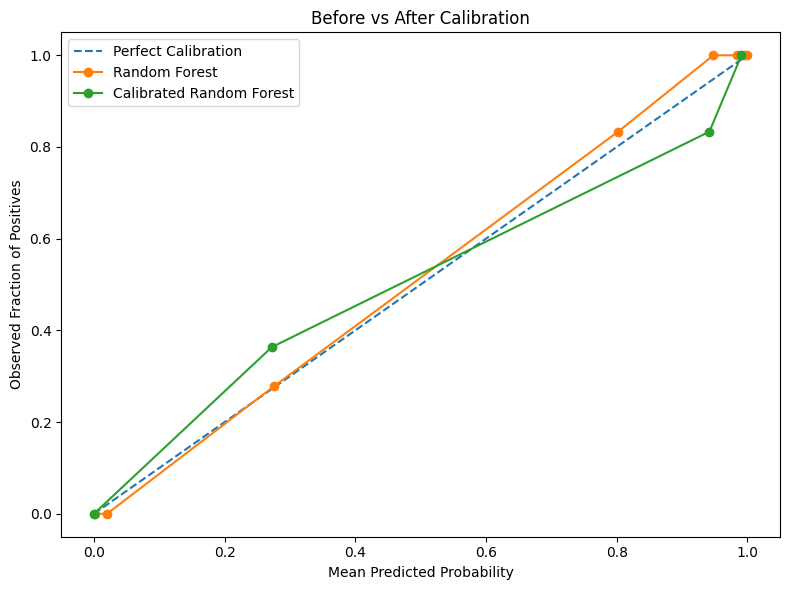

In [5]:
calibrated_rf=CalibratedClassifierCV(
    estimator=RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    method="isotonic",
    cv=5
)

calibrated_rf.fit(X_train,y_train)
cal_rf_prob=calibrated_rf.predict_proba(X_test)[:,1]

cal_true,cal_predicted=calibration_curve(
    y_test,cal_rf_prob,n_bins=8,strategy="quantile"
)

plt.figure(figsize=(8,6))
plt.plot([0,1],[0,1],linestyle="--",label="Perfect Calibration")
plt.plot(rf_predicted,rf_true,marker="o",label="Random Forest")
plt.plot(cal_predicted,cal_true,marker="o",label="Calibrated Random Forest")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")
plt.title("Before vs After Calibration")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Compare probability quality


In [6]:
comparison=pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","Calibrated Random Forest"],
    "Accuracy":[
        accuracy_score(y_test,(log_prob>=0.5).astype(int)),
        accuracy_score(y_test,(rf_prob>=0.5).astype(int)),
        accuracy_score(y_test,(cal_rf_prob>=0.5).astype(int))
    ],
    "Log Loss":[
        log_loss(y_test,log_prob),
        log_loss(y_test,rf_prob),
        log_loss(y_test,cal_rf_prob)
    ]
})

display(comparison.round(4))


,Model,Accuracy,Log Loss
0,Logistic Regression,0.958,0.0872
1,Random Forest,0.958,0.1046
2,Calibrated Random Forest,0.958,0.1111


## Enterprise intuition

Imagine a fraud model outputs:

`Fraud Probability = 0.80`

If it is well calibrated, cases around 0.80 should actually be fraud roughly 80% of the time over many cases.

That matters when thresholds drive operations:

- > 0.90 → auto-block
- 0.70–0.90 → urgent review
- 0.40–0.70 → standard review

Poorly calibrated probabilities can make these thresholds misleading.


## What does this teach?

- Good classification accuracy does not guarantee good probabilities.
- Calibration compares predicted confidence with observed outcomes.
- Calibration curves reveal overconfidence or underconfidence.
- Calibrated probabilities matter when decisions use risk thresholds.
- Calibration should be learned without touching the final test set.
- Better calibration does not necessarily mean higher accuracy.

> **When a model says 80%, that 80% should mean something.**


## References

- https://scikit-learn.org/stable/modules/calibration.html
- https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibratedClassifierCV.html
- https://dl.acm.org/doi/10.1145/1102351.1102430
